# Resonator Spectroscopy

### Prerequisites
This guide assumes you have a configured `DeviceSetup` as well as `Qubit` objects with assigned parameters. Please see [our tutorials](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/index.html) if you need to create your setup and qubits for the first time. 

You can run this notebook on real hardware in the lab. However, if you don't have the hardware at your disposal, you can also run the notebook "as is" using an emulated session (see below). 

If you are just getting started with the LabOne Q Applications Library, please don't hesitate to reach out to us at info@zhinst.com.

### Background
In this how-to guide, you'll perform a measurement to find the optimal response frequency of a resonator to maximize signal-to-noise for a qubit measurement. The LabOne Q Applications Library provides different experiment workflows to achieve this task. You can either just sweep the frequency of a measure-pulse using the `resonator_spectroscopy` experiment workflow, or perform a 2D sweep to optimize at the same time the amplitude of the measure-pulse (the `resonator_spectroscopy_amplitude` experiment workflow). The measure-pulse modulated at different frequencies will be sent on a readout line traversing multiple resonators each coupled with one qubit.

When isolated, a superconducting resonator can be fully described simply by the magnetic flux threaded through the inductor $\phi$ and the difference $n$ in the number of charges on the two plates of the capacitor in units of Copper pairs. In this case, the resulting Hamiltonian will be

$$H = \frac{E_L}{2}\phi^2 + 4 E_C n^2$$

The above Hamiltonian is changed when the resonator is in contact with an external environment, consisting of coupling to other quantum elements and other undesired interactions with a dissipative bath. This more general Hamiltonian can be simplified in the limit where the resonator and the quantum element are far detuned and there is weak anharmonicity. In this regime, the net effect of this interaction will be a shift in the frequency of both quantum elements due to the Lamb shift. For small couplings, the change in frequency for the resonator will be

$$\omega^{1}_R \approx \omega_R + \frac{g^2}{\Delta}$$

where $g$ is the coupling between the two elements and $\Delta$ is their difference in frequency. This frequency shift effectively allows us to measure the state of a quantum element by checking the response of its coupled resonator. This method is called *dispersive readout*.

![](../../../images/resonators_and_qubits.svg "Sketch of the layout of a simple chip with each qubits coupled to a resonator.")

Given this context, we see now that the scope of this experiment workflow is to characterize the resonator at a particular qubit state, typically when this is in its ground state, by looking at the response in the readout line to different frequencies. In practice, the exact response depends on the details of the circuit. Here is an example of how data would look like when several resonators are connected to the same line:

![](../../../images/resonator_result.png "Plot of Resonator spectroscopy where the different frequencies scanned are depicted on the x-axis and the absolute value of the integration is presented in the y-axis.")

### Imports

You'll start by importing `laboneq.simple`.

In [1]:
from laboneq.simple import *

### Define your experimental setup

Let's define our experimental setup. We will need:

* a [DeviceSetup](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/00_device_setup/concepts/index.html)

* `n` [TunableTransmonQubits](https://docs.zhinst.com/labone_q_user_manual/applications_library/reference/qpu_types/tunable_transmon.html#laboneq_applications.qpu_types.tunable_transmon.TunableTransmonQubit)

* a set of [TunableTransmonOperations](https://docs.zhinst.com/labone_q_user_manual/applications_library/reference/qpu_types/tunable_transmon.html#laboneq_applications.qpu_types.tunable_transmon.TunableTransmonOperations)

* a [QPU](https://docs.zhinst.com/labone_q_user_manual/core/reference/dsl/quantum.html#laboneq.dsl.quantum.qpu.QPU)

Here, we will be brief. We will mainly provide the code to obtain these objects. To learn more, check out these other tutorials:

* Details about [defining your experimental setup](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/getting_started.html)

* [Qubit parameters and how quantum operations use them](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/quantum_operations.html)

* [Quantum operations in general](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/04_quantum_processing_unit/tutorials/00_quantum_operations.html)

* [Logbooks and data saving with Workflows](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/logbooks.html)

We will use 3 `TunableTransmonQubits` in this guide. Change this number to the one describing your setup.

In [2]:
number_of_qubits = 3

#### DeviceSetup

This guide requires a setup that can drive and readout tunable transmon qubits. Your setup could contain an SHFQC+ instrument, or an SHFSG and an SHFQA instruments. Here, we will use an SHFQC+ with 6 signal generation channels and a PQSC.

If you have used LabOne Q before and already have a `DeviceSetup` for your setup, you can reuse that.

If you do not have a `DeviceSetup`, you can create one using the code below. Just change the device numbers to the ones in your rack and adjust any other input parameters as needed.

In [3]:
from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor

descriptor = generate_descriptor(
    pqsc=["DEV10001"],
    shfqc_6=["DEV12001"],
    number_data_qubits=number_of_qubits,
    multiplex=True,
    number_multiplex=number_of_qubits,
    include_cr_lines=False,
    ip_address="localhost",
)
setup = DeviceSetup.from_descriptor(descriptor, "localhost")

/opt/homebrew/anaconda3/envs/pico-thermo/lib/python3.13/site-packages/laboneq/dsl/device/_device_setup_generator.py:262: FutureWarning: Explicit ZSYNCS connections are deprecated and currently ignored. Remove them from the device setup descriptor. This will be a hard error in a future version.
  modifier.add_connection(


#### Qubits

We will generate 3 `TunableTransmonQubits` from the logical signal groups in our `DeviceSetup`. The names of the logical signal groups, `q0`, `q1`, `q2`, will be the UIDs of the qubits. Moreover, the qubits will have the same logical signal lines as the ones of the logical signal groups in the `DeviceSetup`.

In [5]:
from laboneq_applications.qpu_types.tunable_transmon import (
    TunableTransmonQubit,
)

qubits = TunableTransmonQubit.from_device_setup(setup)

In [6]:
for q in qubits:
    print("-------------")
    print("Qubit UID:", q.uid)
    print("Qubit logical signals:")
    for sig, lsg in q.signals.items():
        print(f"  {sig:<10} ('{lsg:>10}')")

-------------
Qubit UID: q0
Qubit logical signals:
  drive      ('  q0/drive')
  drive_ef   ('q0/drive_ef')
  measure    ('q0/measure')
  acquire    ('q0/acquire')
-------------
Qubit UID: q1
Qubit logical signals:
  drive      ('  q1/drive')
  drive_ef   ('q1/drive_ef')
  measure    ('q1/measure')
  acquire    ('q1/acquire')
-------------
Qubit UID: q2
Qubit logical signals:
  drive      ('  q2/drive')
  drive_ef   ('q2/drive_ef')
  measure    ('q2/measure')
  acquire    ('q2/acquire')


Configure the qubit parameters to reflect the properties of the qubits on your QPU using the following code:

In [7]:
for q in qubits:
    q.parameters.ge_drive_pulse["sigma"] = 0.25
    q.parameters.readout_amplitude = 0.5
    q.parameters.reset_delay_length = 1e-6
    q.parameters.readout_range_out = -25
    q.parameters.readout_lo_frequency = 7.4e9

qubits[0].parameters.drive_lo_frequency = 6.4e9
qubits[0].parameters.resonance_frequency_ge = 6.3e9
qubits[0].parameters.resonance_frequency_ef = 6.0e9
qubits[0].parameters.readout_resonator_frequency = 7.0e9

qubits[1].parameters.drive_lo_frequency = 6.4e9
qubits[1].parameters.resonance_frequency_ge = 6.5e9
qubits[1].parameters.resonance_frequency_ef = 6.3e9
qubits[1].parameters.readout_resonator_frequency = 7.3e9

qubits[2].parameters.drive_lo_frequency = 6.0e9
qubits[2].parameters.resonance_frequency_ge = 5.8e9
qubits[2].parameters.resonance_frequency_ef = 5.6e9
qubits[2].parameters.readout_resonator_frequency = 7.2e9

#### Quantum Operations

Create the set of `TunableTransmonOperations`:

In [8]:
from laboneq_applications.qpu_types.tunable_transmon import TunableTransmonOperations

qops = TunableTransmonOperations()

#### QPU

Create the `QPU` object from the qubits and the quantum operations

In [9]:
from laboneq.dsl.quantum import QPU

qpu = QPU(qubits, quantum_operations=qops)

#### Alternatively, load from a file

If you you already have a `DeviceSetup` and a `QPU` stored in `.json` files, you can simply load them back using the code below:

```python
from laboneq import serializers

setup = serializers.load(full_path_to_device_setup_file)
qpu = serializers.load(full_path_to_qpu_file)

qubits = qpu.quantum_elements
qops = qpu.quantum_operations
```

### Connect to Session

In [10]:
session = Session(setup)
session.connect(do_emulation=True)  # do_emulation=False when at a real setup

[2026.06.22 16:12:41.894] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/laboneq_output/log
[2026.06.22 16:12:41.905] INFO    VERSION: laboneq 26.4.0
[2026.06.22 16:12:41.907] INFO    Connecting to data server at localhost:8004
[2026.06.22 16:12:41.910] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.0.940 at localhost:8004
[2026.06.22 16:12:41.913] INFO    Configuring the device setup
[2026.06.22 16:12:41.948] INFO    The device setup is configured


### Create a `FolderStore` for Saving Data

The experiment `Workflows` can automatically save the inputs and outputs of all their tasks to the folder path we specify when instantiating the `FolderStore`. Here, we choose the current working directory.

In [11]:
# import FolderStore from the `workflow` namespace of LabOne Q, which was imported
# from `laboneq.simple`
from pathlib import Path

folder_store = workflow.logbook.FolderStore(Path.cwd())

We disable saving in this guide. To enable it, simply run `folder_store.activate()`.

In [12]:
folder_store.deactivate()

### Optional: Configure the LoggingStore

You can also activate/deactivate the `LoggingStore`, which is used for displaying the `Workflow` logging information in the notebook; see again the [tutorial on Recording Experiment Workflow Results](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/logbooks.html) for details.

Displaying the `Workflow` logging information is activated by default, but here we deactivate it to shorten the outputs, which are not very meaningful in emulation mode.

**We recommend that you do not deactivate the Workflow logging in practice.**

In [13]:
from laboneq.workflow.logbook import LoggingStore

logging_store = LoggingStore()
logging_store.deactivate()

### Running the Experiment Workflow

You'll now instantiate the experiment workflow and run it. For more details on what experiment workflows are and what tasks they execute, see the [Experiment Workflows tutorial](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/experiment_workflows.html).

You'll start by importing `numpy`, the resonator-spectroscopy experiment workflows from `laboneq_applications`, as well as `plot_simulation` for inspecting the experiment sequence.

In [14]:
import numpy as np
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation

from laboneq_applications.experiments import (
    resonator_spectroscopy,
    resonator_spectroscopy_amplitude,
)

Let's first create the options class for the resonator-spectroscopy experiment and inspect it using the `show_fields` function from the `workflow` namespace of LabOne Q, which was imported from `laboneq.simple`:

In [15]:
options = resonator_spectroscopy.experiment_workflow.options()
workflow.show_fields(options)

Option Fields
acquisition_type:
	Description: Acquisition type to use for the experiment.
	Classes and Defaults: [('ResonatorSpectroscopyExperimentOptions', AcquisitionType.SPECTROSCOPY_IQ)], 

active_reset:
	Description: Whether to use active reset.
	Classes and Defaults: [('ResonatorSpectroscopyExperimentOptions', False)], 

active_reset_repetitions:
	Description: The number of times to repeat the active resets.
	Classes and Defaults: [('ResonatorSpectroscopyExperimentOptions', 1)], 

active_reset_states:
	Description: The qubit states to actively reset.
	Classes and Defaults: [('ResonatorSpectroscopyExperimentOptions', 'ge')], 

averaging_mode:
	Description: Averaging mode to use for the experiment.
	Classes and Defaults: [('ResonatorSpectroscopyExperimentOptions', AveragingMode.CYCLIC)], 

cal_states:
	Description: The states to prepare in the calibration traces.Can be any string or tuple made from combining the characters 'g', 'e', 'f'.
	Classes and Defaults: [('PlotRawDataOptions

Notice that, unless we change it:

- the experiment is run in `AcquisitionType.SPECTROSCOPY_IQ` and `AveragingMode.CYCLIC`, using 1024 averages (`count`)
- there is a waiting time of $1\mu$ s between the end of every acquisition and the playback of the subsequent readout pulse (`spectroscopy_reset_delay`)
- the analysis workflow will run automatically (`do_analysis=True`)
- the figures produced by the analysis are automatically closed (`close_figures=True`)
- the qubit parameters will not be updated (`update=False`)

Here, let's disable closing the figures produced by the analysis so we see them in the cell output. Note however that the fit attempted by the analysis routine is meaningless in emulation mode because we do not have data acquired at a real-qubit setup.

In [16]:
options.close_figures(False)

Now we run the experiment workflow on the first qubit. 

[2026.06.22 16:24:25.458] INFO    Starting LabOne Q Compiler run...
[2026.06.22 16:24:25.467] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.06.22 16:24:25.467] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.06.22 16:24:25.475] INFO    Schedule completed. [0.007 s]
[2026.06.22 16:24:25.505] INFO    Code generation completed for all AWGs. [0.030 s]
[2026.06.22 16:24:25.507] INFO    Completed compilation step 1 of 1. [0.039 s]
[2026.06.22 16:24:25.514] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.06.22 16:24:25.514] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.22 16:24:25.515] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.06.22 16:24:25.515] INFO      SHFQC_DEV12001        0         21            0           1      8000  
[2026.06.22 16:24:25.515] INFO      SHFQC_DEV12001_sg   

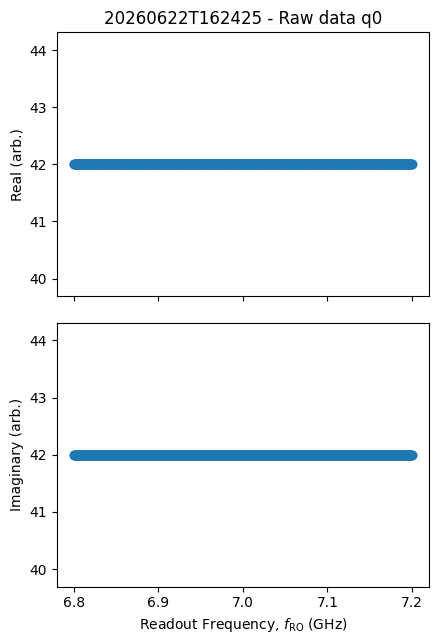

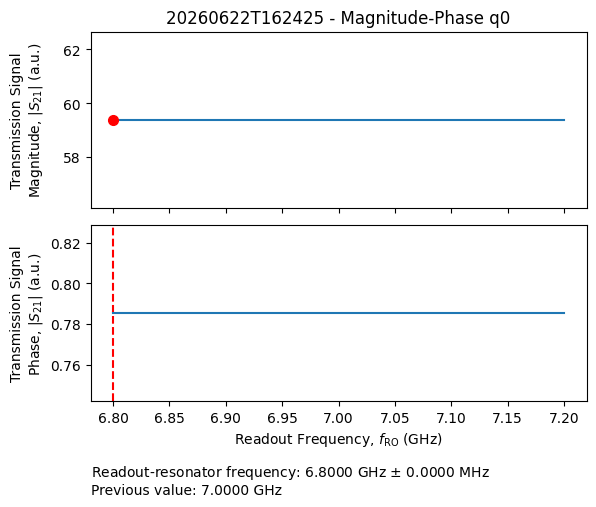

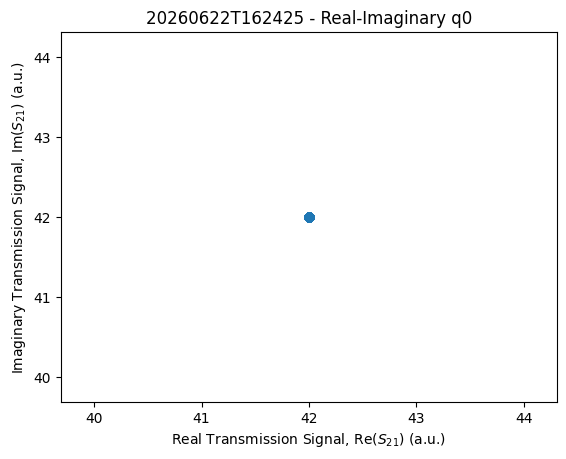

In [17]:
# our qubits live here in the demo setup:
qubit = qubits[0]

exp_workflow = resonator_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit.uid,
    frequencies=np.linspace(6.8e9, 7.2e9, 1001),
    options=options,
)

workflow_results = exp_workflow.run()

#### Inspect the Tasks That Were Run

In [18]:
for t in workflow_results.tasks:
    print(t)

TaskResult(name=temporary_qpu, index=())
TaskResult(name=temporary_quantum_elements_from_qpu, index=())
TaskResult(name=create_experiment, index=())
TaskResult(name=compile_experiment, index=())
TaskResult(name=run_experiment, index=())
WorkflowResult(name=analysis_workflow, index=())


#### Inspect the Output Simulation

You can also inspect the compiled experiment and plot the simulated output:

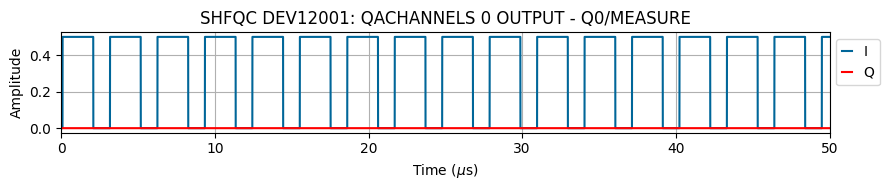

In [19]:
compiled_experiment = workflow_results.tasks["compile_experiment"].output
plot_simulation(compiled_experiment, length=50e-6, signal_names_to_show=["measure"])

#### Inspecting the Source Code of the Pulse-Sequence Creation Task

You can inspect the source code of the `create_experiment` task defined in `ramsey` to see how the experiment pulse sequence is created using quantum operations. To learn more about the latter, see the [Quantum Operations tutorial](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/quantum_operations.html).

In [20]:
resonator_spectroscopy.create_experiment.src

'@workflow.task\n@dsl.qubit_experiment\ndef create_experiment(\n    qpu: QPU,\n    qubit: QuantumElement,\n    frequencies: ArrayLike,\n    options: ResonatorSpectroscopyExperimentOptions | None = None,\n) -> Experiment:\n    """Creates a Resonator Spectroscopy Experiment.\n\n    Arguments:\n        qpu:\n            The qpu consisting of the original qubits and quantum operations.\n        qubit:\n            The qubit to run the experiments on. May be either a single\n            qubit or a list of qubits.\n        frequencies:\n            The resonator frequencies to sweep over for each qubit.\n            It must be a list of lists of numbers or arrays.\n        options:\n            The options for building the experiment.\n            See [ResonatorSpectroscopyExperimentOptions] and [BaseExperimentOptions] for\n            accepted options.\n            Overwrites the options from [BaseExperimentOptions].\n\n    Returns:\n        experiment:\n            The generated LabOne Q experiment instance to be compiled and executed.\n\n    Raises:\n        ValueError:\n            If the acquisition_type is not AcquisitionType.SPECTROSCOPY.\n\n    Example:\n        ```python\n        options = {\n            "count": 10,\n            "spectroscopy_reset_delay": 3e-6\n        }\n        options = TuneupExperimentOptions(**options)\n        setup = DeviceSetup("my_device")\n        qpu = QPU(\n            quantum_elements=[TunableTransmonQubit("q0"), TunableTransmonQubit("q1")],\n            quantum_operations=TunableTransmonOperations(),\n        )\n        temp_qubits = qpu.copy_quantum_elements()\n        create_experiment(\n            qpu=qpu,\n            qubit=temp_qubits[0],\n            frequencies=np.linspace(7.1e9, 7.6e9, 501),\n            options=options,\n        )\n        ```\n    """\n    # Define the custom options for the experiment\n    opts = ResonatorSpectroscopyExperimentOptions() if options is None else options\n    qubit, frequencies = validation.validate_and_convert_single_qubit_sweeps(\n        qubit, frequencies\n    )\n    # guard against wrong options for the acquisition type\n    if AcquisitionType(opts.acquisition_type) != AcquisitionType.SPECTROSCOPY:\n        raise ValueError(\n            "The only allowed acquisition_type for this experiment"\n            "is \'AcquisitionType.SPECTROSCOPY\' (or \'spectrsocopy\')"\n            "because it contains a sweep"\n            "of the frequency of a hardware oscillator.",\n        )\n\n    qop = qpu.quantum_operations\n    with dsl.acquire_loop_rt(\n        count=opts.count,\n        averaging_mode=opts.averaging_mode,\n        acquisition_type=opts.acquisition_type,\n        repetition_mode=opts.repetition_mode,\n        repetition_time=opts.repetition_time,\n        reset_oscillator_phase=opts.reset_oscillator_phase,\n    ):\n        with dsl.sweep(\n            name=f"freq_{qubit.uid}",\n            parameter=SweepParameter(f"frequencies_{qubit.uid}", frequencies),\n        ) as frequency:\n            qop.set_frequency(qubit, frequency=frequency, readout=True)\n            if opts.use_cw:\n                qop.acquire(\n                    qubit,\n                    handle=dsl.handles.result_handle(qubit.uid),\n                    kernel_pulses="continuous",\n                )\n            else:\n                qop.measure(qubit, handle=dsl.handles.result_handle(qubit.uid))\n            qop.delay(qubit, opts.spectroscopy_reset_delay)\n'

To learn more about how to work with experiment `Workflows`, check out the [Experiment Workflows tutorial](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/experiment_workflows.html).

Here, let's briefly inspect the analysis-workflow results.

#### Analysis Results

Let's check what tasks were run as part of the analysis workflow:

In [21]:
analysis_workflow_results = workflow_results.tasks["analysis_workflow"]
for t in analysis_workflow_results.tasks:
    print(t)

TaskResult(name=calculate_signal_magnitude_and_phase, index=())
TaskResult(name=fit_data, index=())
TaskResult(name=extract_qubit_parameters, index=())
TaskResult(name=plot_raw_complex_data_1d, index=())
TaskResult(name=plot_magnitude_phase, index=())
TaskResult(name=plot_real_imaginary, index=())


We can access the qubit parameters extracted by the analysis from the output of the analysis-workflow:

In [22]:
from pprint import pprint

pprint(analysis_workflow_results.output)

{'new_parameter_values': {'q0': {'readout_resonator_frequency': 6800000000.0+/-0}},
 'old_parameter_values': {'q0': {'readout_resonator_frequency': 7000000000.0}}}


Check out the [Experiment Workflows tutorial](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/experiment_workflows.html) to see how you can manually update the qubit parameters to these new values, or reset them to the old ones. 

### Sweep the amplitude at the Same Time

Getting back to our found parameters, we now repeat the resonator-spectroscopy experiment while sweeping the amplitude at the same time. Since the analysis and the interface are different, a dedicated workflow is used, but the input only differs slightly. Note that, since the amplitude is swept in near-time, the change in amplitude will not be visible in the `OutputSimulator`.

In [23]:
exp_workflow_amp = resonator_spectroscopy_amplitude.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit.uid,
    frequencies=np.linspace(6.5e9, 7.5e9, 1001),
    amplitudes=np.linspace(0.1, 0.9, 10),
)

workflow_results_amp = exp_workflow_amp.run()

[2026.06.22 16:42:06.840] INFO    Starting LabOne Q Compiler run...
[2026.06.22 16:42:06.847] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.06.22 16:42:06.848] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.06.22 16:42:06.859] INFO    Schedule completed. [0.011 s]
[2026.06.22 16:42:06.907] INFO    Code generation completed for all AWGs. [0.048 s]
[2026.06.22 16:42:06.909] INFO    Completed compilation step 1 of 10. [0.060 s]
[2026.06.22 16:42:06.909] INFO    Skipping compilation for next step(s)...
[2026.06.22 16:42:06.911] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.06.22 16:42:06.911] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.22 16:42:06.911] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.06.22 16:42:06.911] INFO      SHFQC_DEV12001        0         21            0     

Great! You've now run your resonator-spectroscopy experiment. Check out other experiments in this manual to keep characterizing your qubits.